11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


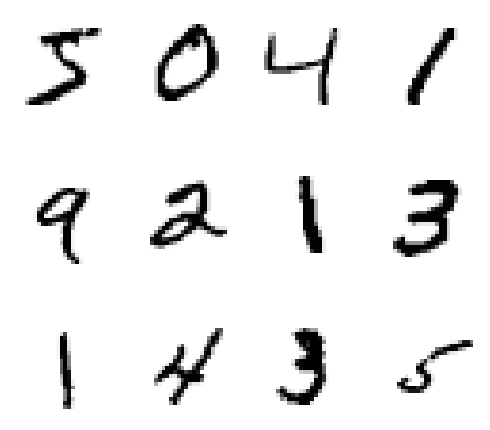

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7772 - loss: 0.7757 - val_accuracy: 0.9286 - val_loss: 0.2399
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9315 - loss: 0.2337 - val_accuracy: 0.9475 - val_loss: 0.1739
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9528 - loss: 0.1651 - val_accuracy: 0.9550 - val_loss: 0.1427
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9607 - loss: 0.1327 - val_accuracy: 0.9612 - val_loss: 0.1287
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9660 - loss: 0.1156 - val_accuracy: 0.9624 - val_loss: 0.1198
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9707 - loss: 0.1027 - val_accuracy: 0.9678 - val_loss: 0.1093
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9723 - loss: 0.0934 - val_accuracy: 0.9699 - val_loss: 0.1026
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9749 - loss: 0.0822 - val_accuracy: 

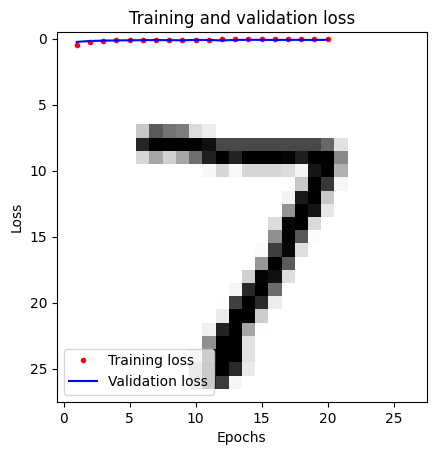

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
ANS: 4


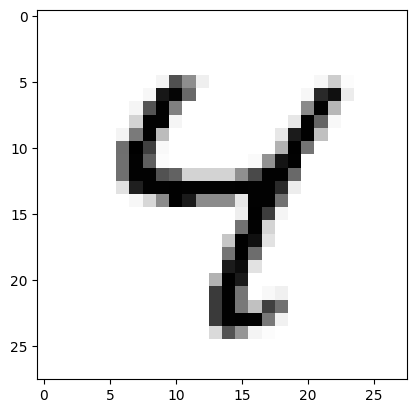

In [1]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from numpy import argmax

(X_train, y_train), (X_valid, y_valid) = tf.keras.datasets.mnist.load_data()

plt.figure(figsize=(5,5))
for k in range(12):
    plt.subplot(3, 4, k+1)
    plt.imshow(X_train[k], cmap='Greys')
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.imshow(X_valid[0], cmap='Greys')

ORI_X_valid = X_valid
ORI_y_valid = y_valid

X_train = X_train.reshape(60000, 784).astype('float32') / 255
X_valid = X_valid.reshape(10000, 784).astype('float32') / 255

n_classes = 10
y_train = keras.utils.to_categorical(y_train, n_classes)
y_valid = keras.utils.to_categorical(y_valid, n_classes)

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.1), metrics=['accuracy'])

history = model.fit(X_train, y_train, batch_size=128, epochs=20, verbose=1, validation_data=(X_valid, y_valid))

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'r.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

idx = 6
plt.imshow(ORI_X_valid[idx], cmap='Greys')
prediction = model.predict(X_valid[idx : (idx + 1)])[0]
ans = argmax(prediction)
print("ANS:", ans)


In [2]:
# convert and save the model in TFLite format

!mkdir output
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
open("output/mnist_model.tflite", "wb").write(tflite_model)

Saved artifact at '/tmp/tmptjk3w2me'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139520313002896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139520313003856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139520313006928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139520313007312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139520313007120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139520313007696: TensorSpec(shape=(), dtype=tf.resource, name=None)


222304

In [3]:

# save the TFLite file as a C source file -- # save the TFLite file as a C source file

!apt-get -qq install xxd
!xxd -i output/mnist_model.tflite > output/mnist_model.h

In [ ]:
import subprocess

# Define input and output file names
input_model = "mnist_model.tflite"
output_header = "mnist_model.h"

# Convert model to C array
with open(input_model, "rb") as f:
    data = f.read()

# Generate the C header content
c_array = ", ".join(f"0x{b:02x}" for b in data)
header_content = f"""
#ifndef MNIST_MODEL_H
#define MNIST_MODEL_H

#include <stdint.h>

const unsigned char mnist_model[] = {{
    {c_array}
}};

const unsigned int mnist_model_len = {len(data)};

#endif // MNIST_MODEL_H
"""

# Save to .h file
with open(output_header, "w") as f:
    f.write(header_content)

print(f"Header file '{output_header}' generated successfully.")


Header file 'mnist_model.h' generated successfully.


In [ ]:
import tensorflow as tf
import numpy as np

# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (_, _) = mnist.load_data()

# Select the first image (you can modify this to select more)
num_images = 10  # Number of images to include
selected_images = train_images[:num_images].astype(np.uint8)

# Convert images to a flattened array
flattened_images = selected_images.reshape(num_images, -1)  # Flatten each image

# Generate C header file content
header_content = f"""
#ifndef IMAGE_DATA_H
#define IMAGE_DATA_H

#include <stdint.h>

#define NUM_IMAGES {num_images}
#define IMAGE_SIZE 28*28

const uint8_t image_data[NUM_IMAGES][IMAGE_SIZE] = {{
"""

for img in flattened_images:
    hex_values = ", ".join(f"0x{pixel:02x}" for pixel in img)
    header_content += f"    {{{hex_values}}},\n"

header_content += """
};

#endif // IMAGE_DATA_H
"""

# Write to image_data.h file
with open("image_data.h", "w") as f:
    f.write(header_content)

print("Header file 'image_data.h' generated successfully.")


Header file 'image_data.h' generated successfully.
